Done — 3.03s simulated travel time


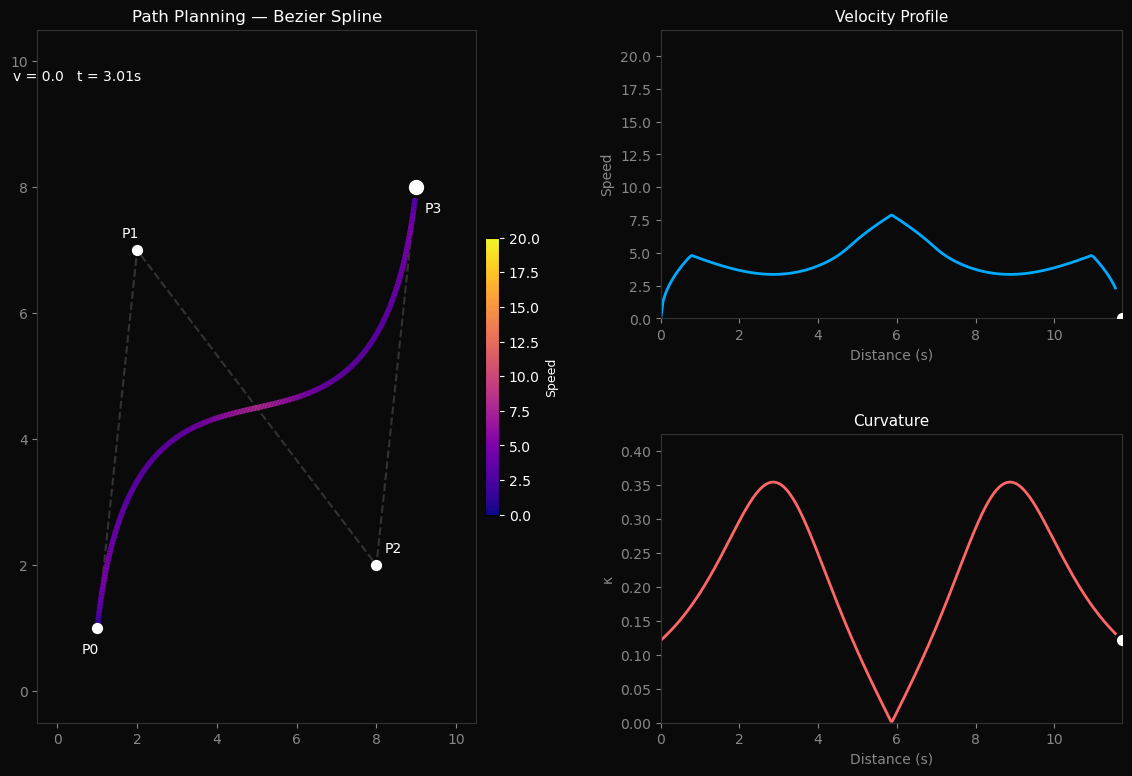

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec

# --- Bezier math ---
P0, P1, P2, P3 = np.array([1.0,1.0]), np.array([2.0,7.0]), np.array([8.0,2.0]), np.array([9.0,8.0])

def lerp(A, B, t): return A + t * (B - A)
def bezier(t):
    mt = 1 - t
    return mt**3*P0 + 3*mt**2*t*P1 + 3*mt*t**2*P2 + t**3*P3

def bezier_deriv(t):
    mt = 1 - t
    return 3*mt**2*(P1-P0) + 6*mt*t*(P2-P1) + 3*t**2*(P3-P2)

def bezier_deriv2(t):
    return 6*(1-t)*(P2-2*P1+P0) + 6*t*(P3-2*P2+P1)

def curvature(t):
    d1 = bezier_deriv(t)
    d2 = bezier_deriv2(t)
    cross = d1[0]*d2[1] - d1[1]*d2[0]
    denom = (d1[0]**2 + d1[1]**2)**1.5
    return abs(cross/denom) if denom > 1e-9 else 0.0

# --- Sample the curve ---
N = 300
ts = np.linspace(0, 1, N)
pts = np.array([bezier(t) for t in ts])

# Arc-length parameterization
diffs = np.diff(pts, axis=0)
seg_lens = np.sqrt((diffs**2).sum(axis=1))
s = np.concatenate([[0], np.cumsum(seg_lens)])
total_len = s[-1]

# Curvature at each point
kappas = np.array([curvature(t) for t in ts])

# --- Velocity profile (mirrors your Rust forward/backward pass) ---
MAX_VEL = 20.0
MAX_ACC = 15.0
MAX_LAT_ACC = 8.0*.5

velocities = np.zeros(N)
for i in range(N):
    k = kappas[i]
    v_lat = np.sqrt(MAX_LAT_ACC / k) if k > 1e-9 else MAX_VEL
    velocities[i] = min(MAX_VEL, v_lat)

# Forward pass
velocities[0] = 0.0
for i in range(N-1):
    ds = s[i+1] - s[i]
    v_possible = np.sqrt(velocities[i]**2 + 2*MAX_ACC*ds)
    velocities[i+1] = min(velocities[i+1], v_possible)

# Backward pass
velocities[-1] = 0.0
for i in range(N-2, -1, -1):
    ds = s[i+1] - s[i]
    v_possible = np.sqrt(velocities[i+1]**2 + 2*MAX_ACC*ds)
    velocities[i] = min(velocities[i], v_possible)

# Time integration
times = np.zeros(N)
for i in range(N-1):
    v_avg = (velocities[i] + velocities[i+1])
    dt = 2*(s[i+1]-s[i]) / v_avg if v_avg > 1e-9 else 0.0
    times[i+1] = times[i] + dt
total_time = times[-1]

# --- Figure layout ---
fig = plt.figure(figsize=(14, 9), facecolor='#0a0a0a')
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax_path   = fig.add_subplot(gs[:, 0])   # left: path (full height)
ax_vel    = fig.add_subplot(gs[0, 1])   # top right: velocity profile
ax_curv   = fig.add_subplot(gs[1, 1])   # bottom right: curvature

for ax in [ax_path, ax_vel, ax_curv]:
    ax.set_facecolor('#0a0a0a')
    ax.tick_params(colors='#888888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.title.set_color('white')
    ax.xaxis.label.set_color('#888888')
    ax.yaxis.label.set_color('#888888')

ax_path.set_xlim(-0.5, 10.5); ax_path.set_ylim(-0.5, 10.5)
ax_path.set_title('Path Planning — Bezier Spline', fontsize=12)
ax_vel.set_xlim(0, total_len); ax_vel.set_ylim(0, MAX_VEL * 1.1)
ax_vel.set_title('Velocity Profile', fontsize=11)
ax_vel.set_xlabel('Distance (s)'); ax_vel.set_ylabel('Speed')
ax_curv.set_xlim(0, total_len); ax_curv.set_ylim(0, kappas.max() * 1.2)
ax_curv.set_title('Curvature', fontsize=11)
ax_curv.set_xlabel('Distance (s)'); ax_curv.set_ylabel('κ')

ctrl_pts = np.array([P0, P1, P2, P3])
ax_path.plot(ctrl_pts[:,0], ctrl_pts[:,1], '--', color='#333333', lw=1.5)
ax_path.scatter(ctrl_pts[:,0], ctrl_pts[:,1], color='white', s=50, zorder=5)
for pt, lbl, off in zip(ctrl_pts, ['P0','P1','P2','P3'], [(-0.4,-0.4),(-0.4,0.2),(0.2,0.2),(0.2,-0.4)]):
    ax_path.text(pt[0]+off[0], pt[1]+off[1], lbl, color='white', fontsize=10)

# Colormap segments for heatmap (drawn once, revealed progressively)
norm_vel = plt.Normalize(0, MAX_VEL)
cmap = plt.get_cmap('plasma')

# --- Animation stages ---
# Stage 1 (frames 0..120):   draw curve + de Casteljau lines
# Stage 2 (frames 120..240): reveal curvature heatmap over the curve
# Stage 3 (frames 240..360): plot velocity & curvature graphs
# Stage 4 (frames 360..480): drive dot along path at correct speed

STAGE1, STAGE2, STAGE3, STAGE4 = 120, 120, 120, 120
TOTAL = STAGE1 + STAGE2 + STAGE3 + STAGE4

# --- Path ax artists ---
plain_line,  = ax_path.plot([], [], color='cyan', lw=2, zorder=3, alpha=1.0)
heatmap_lc   = LineCollection([], cmap='plasma', norm=norm_vel, lw=4, zorder=4)
ax_path.add_collection(heatmap_lc)
drive_dot,   = ax_path.plot([], [], 'o', color='white', ms=10, zorder=7)
speed_text   = ax_path.text(0.5, 9.7, '', color='white', fontsize=10, ha='center')

# De casteljau artists
l1_lines = [ax_path.plot([], [], '-', color='#00ff88', lw=1, alpha=0.6)[0] for _ in range(3)]
l2_lines = [ax_path.plot([], [], '-', color='#ffff00', lw=1, alpha=0.6)[0] for _ in range(2)]
l3_line,  = ax_path.plot([], [], '-', color='#ff8800', lw=1.5, alpha=0.8)
cast_dots = [ax_path.plot([], [], 'o', color=c, ms=6, zorder=6)[0]
             for c in ['#00ff88','#00ff88','#00ff88','#ffff00','#ffff00','#ff8800']]

# Velocity / curvature graph artists
vel_line,  = ax_vel.plot([], [], color='#00aaff', lw=2)
curv_line, = ax_curv.plot([], [], color='#ff6666', lw=2)
vel_dot,   = ax_vel.plot([], [], 'o', color='white', ms=7, zorder=5)
curv_dot,  = ax_curv.plot([], [], 'o', color='white', ms=7, zorder=5)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm_vel)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_path, fraction=0.03, pad=0.02)
cbar.set_label('Speed', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

drawn_pts = []

def clear_casteljau():
    for l in l1_lines + l2_lines: l.set_data([], [])
    l3_line.set_data([], [])
    for d in cast_dots: d.set_data([], [])

def update(frame):
    # ── STAGE 1: draw curve + de Casteljau ──────────────────────────────
    if frame < STAGE1:
        idx = int((frame / STAGE1) * (N-1))
        drawn_pts.clear()
        drawn_pts.extend(pts[:idx+1])
        arr = np.array(drawn_pts)
        plain_line.set_data(arr[:,0], arr[:,1])

        t = ts[idx]
        Q0 = lerp(P0, P1, t); Q1 = lerp(P1, P2, t); Q2 = lerp(P2, P3, t)
        R0 = lerp(Q0, Q1, t); R1 = lerp(Q1, Q2, t)
        B  = lerp(R0, R1, t)

        for l, (a, b) in zip(l1_lines, [(P0,P1),(P1,P2),(P2,P3)]):
            l.set_data([a[0],b[0]], [a[1],b[1]])
        for l, (a, b) in zip(l2_lines, [(Q0,Q1),(Q1,Q2)]):
            l.set_data([a[0],b[0]], [a[1],b[1]])
        l3_line.set_data([R0[0],R1[0]], [R0[1],R1[1]])
        for d, pt in zip(cast_dots, [Q0,Q1,Q2,R0,R1,B]):
            d.set_data([pt[0]], [pt[1]])

        heatmap_lc.set_segments([])
        drive_dot.set_data([], [])
        speed_text.set_text(f't = {t:.2f}')

    # ── STAGE 2: reveal curvature heatmap ───────────────────────────────
    elif frame < STAGE1 + STAGE2:
        clear_casteljau()
        plain_line.set_data([], [])
        progress = (frame - STAGE1) / STAGE2
        reveal_n = max(2, int(progress * N))

        segs = np.stack([pts[:reveal_n-1], pts[1:reveal_n]], axis=1)
        colors = velocities[:reveal_n-1]
        heatmap_lc.set_segments(segs)
        heatmap_lc.set_array(colors)
        drive_dot.set_data([], [])
        speed_text.set_text('Curvature → Speed limit')

    # ── STAGE 3: plot velocity & curvature graphs ────────────────────────
    elif frame < STAGE1 + STAGE2 + STAGE3:
        progress = (frame - STAGE1 - STAGE2) / STAGE3
        reveal_n = max(2, int(progress * N))

        vel_line.set_data(s[:reveal_n], velocities[:reveal_n])
        curv_line.set_data(s[:reveal_n], kappas[:reveal_n])
        vel_dot.set_data([s[reveal_n-1]], [velocities[reveal_n-1]])
        curv_dot.set_data([s[reveal_n-1]], [kappas[reveal_n-1]])
        speed_text.set_text('Forward / Backward velocity pass')

    # ── STAGE 4: drive dot along path ───────────────────────────────────
    else:
        progress = (frame - STAGE1 - STAGE2 - STAGE3) / STAGE4
        drive_time = progress * total_time
        idx = np.searchsorted(times, drive_time)
        idx = min(idx, N-1)

        drive_dot.set_data([pts[idx,0]], [pts[idx,1]])
        vel_dot.set_data([s[idx]], [velocities[idx]])
        curv_dot.set_data([s[idx]], [kappas[idx]])
        speed_text.set_text(f'v = {velocities[idx]:.1f}   t = {drive_time:.2f}s')

    return ([plain_line, heatmap_lc, drive_dot, speed_text, l3_line, vel_line, curv_line, vel_dot, curv_dot]
            + l1_lines + l2_lines + cast_dots)

ani = animation.FuncAnimation(fig, update, frames=TOTAL, interval=33, blit=True)
ani.save('path_animation.mp4', writer='ffmpeg', dpi=150)
print(f"Done — {total_time:.2f}s simulated travel time")

Done — 7.97s simulated travel time, 840 frames


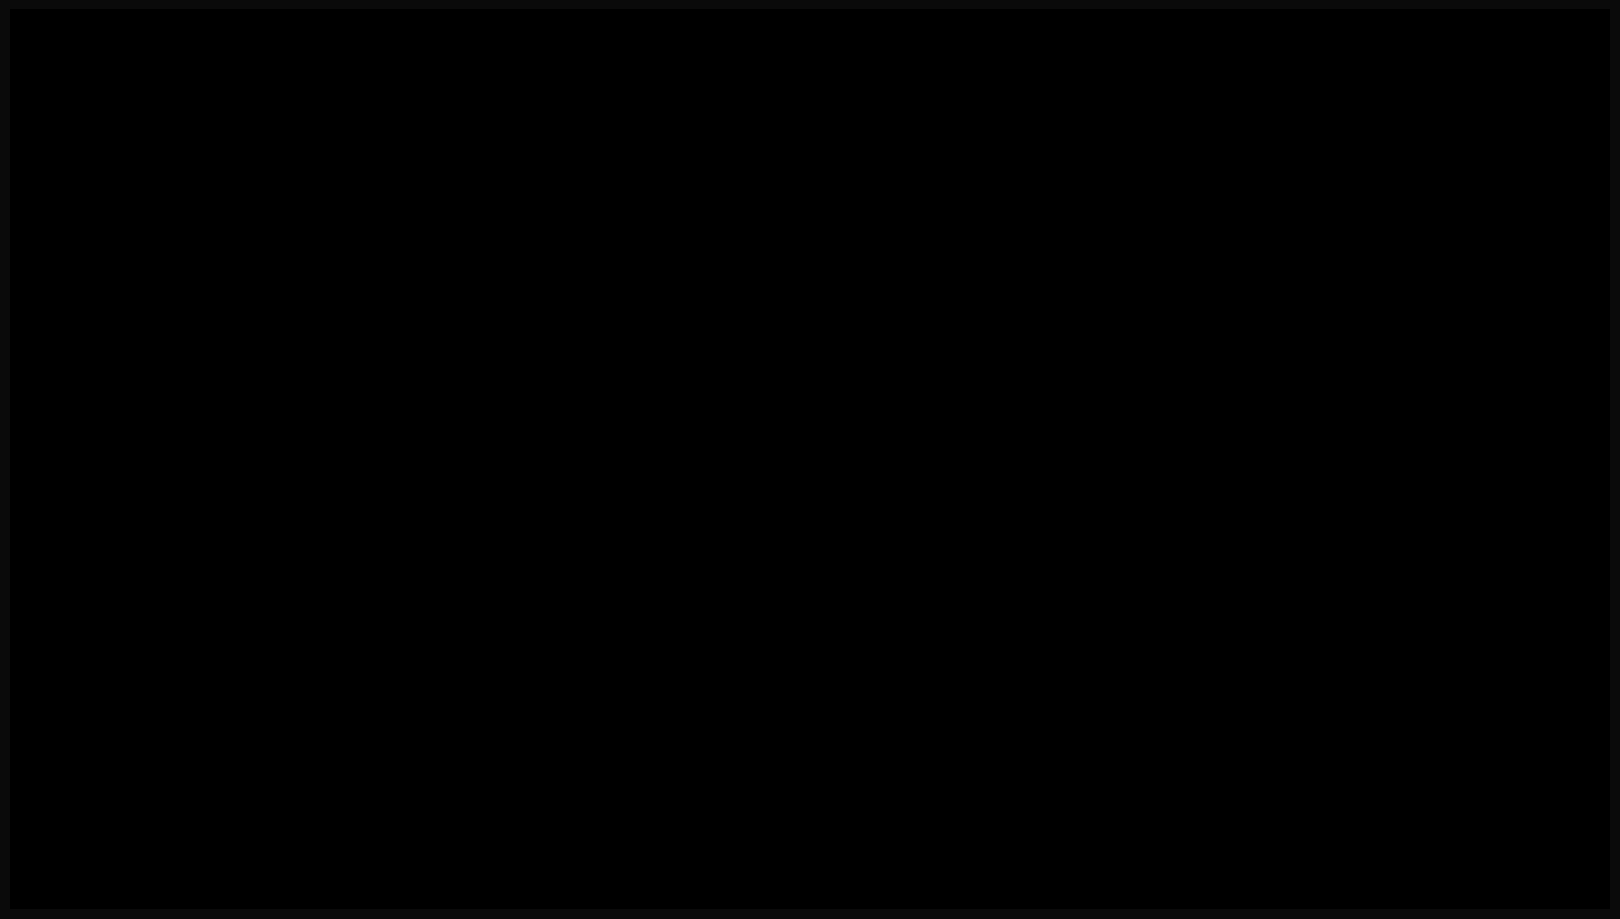

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec

# ── Anchor positions ──────────────────────────────────────────────────────────
anchors = np.array([
    [1.0, 2.0],
    [2.5, 8.0],
    [4.5, 1.5],
    [6.0, 7.5],
    [7.5, 2.5],
    [9.0, 6.0],
], dtype=float)

handles_out = np.array([
    [ 0.8,  1.0],
    [ 1.2, -1.0],
    [ 1.0,  1.0],
    [ 1.0, -1.0],
    [ 0.8,  1.2],
    [ 0.5,  0.5],
], dtype=float)
handles_in = -handles_out

N_SEG = len(anchors) - 1

# ── Bezier math ───────────────────────────────────────────────────────────────
def lerp(A, B, t): return A + t * (B - A)

def bezier_seg(P0, P1, P2, P3, t):
    mt = 1 - t
    return mt**3*P0 + 3*mt**2*t*P1 + 3*mt*t**2*P2 + t**3*P3

def bezier_deriv_seg(P0, P1, P2, P3, t):
    mt = 1 - t
    return 3*mt**2*(P1-P0) + 6*mt*t*(P2-P1) + 3*t**2*(P3-P2)

def bezier_deriv2_seg(P0, P1, P2, P3, t):
    return 6*(1-t)*(P2-2*P1+P0) + 6*t*(P3-2*P2+P1)

def curvature_seg(P0, P1, P2, P3, t):
    d1 = bezier_deriv_seg(P0, P1, P2, P3, t)
    d2 = bezier_deriv2_seg(P0, P1, P2, P3, t)
    cross = d1[0]*d2[1] - d1[1]*d2[0]
    denom = (d1[0]**2 + d1[1]**2)**1.5
    return abs(cross/denom) if denom > 1e-9 else 0.0

# ── Sample each segment ───────────────────────────────────────────────────────
N_PER_SEG = 1000
all_pts, all_kappas, seg_ids = [], [], []

for i in range(N_SEG):
    P0 = anchors[i];              P1 = anchors[i]   + handles_out[i]
    P2 = anchors[i+1] + handles_in[i+1]; P3 = anchors[i+1]
    ts = np.linspace(0, 1, N_PER_SEG, endpoint=(i == N_SEG-1))
    for t in ts:
        all_pts.append(bezier_seg(P0, P1, P2, P3, t))
        all_kappas.append(curvature_seg(P0, P1, P2, P3, t))
        seg_ids.append(i)

pts    = np.array(all_pts)
kappas = np.array(all_kappas)
N      = len(pts)

diffs    = np.diff(pts, axis=0)
seg_lens = np.sqrt((diffs**2).sum(axis=1))
s        = np.concatenate([[0], np.cumsum(seg_lens)])
total_len = s[-1]

# ── Velocity profile ──────────────────────────────────────────────────────────
MAX_VEL = 12.0; MAX_ACC = 12.0; MAX_LAT_ACC = 4.0

velocities = np.array([min(MAX_VEL, np.sqrt(MAX_LAT_ACC / k) if k > 1e-9 else MAX_VEL)
                        for k in kappas])
vel_curvature_limit = velocities.copy()

velocities[0] = 0.0
for i in range(N-1):
    ds = s[i+1] - s[i]
    velocities[i+1] = min(velocities[i+1], np.sqrt(velocities[i]**2 + 2*MAX_ACC*ds))
vel_after_forward = velocities.copy()

velocities[-1] = 0.0
for i in range(N-2, -1, -1):
    ds = s[i+1] - s[i]
    velocities[i] = min(velocities[i], np.sqrt(velocities[i+1]**2 + 2*MAX_ACC*ds))
vel_final = velocities.copy()

times = np.zeros(N)
for i in range(N-1):
    v_avg = vel_final[i] + vel_final[i+1]
    times[i+1] = times[i] + (2*(s[i+1]-s[i]) / v_avg if v_avg > 1e-9 else 0.0)
total_time = times[-1]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9), facecolor='#0a0a0a')
gs  = GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35,
               left=0.07, right=0.96, top=0.93, bottom=0.07)

ax_path = fig.add_subplot(gs[:, 0])
ax_vel  = fig.add_subplot(gs[0, 1])
ax_fwd  = fig.add_subplot(gs[1, 1])
ax_bwd  = fig.add_subplot(gs[2, 1])

for ax in [ax_path, ax_vel, ax_fwd, ax_bwd]:
    ax.set_facecolor('#0a0a0a')
    ax.tick_params(colors='#666666', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
    ax.title.set_color('white')
    ax.xaxis.label.set_color('#777777')
    ax.yaxis.label.set_color('#777777')

ax_path.set_xlim(0, 10.5); ax_path.set_ylim(0, 10)
ax_path.set_title('Path Planning — Multi-Segment Bezier Spline', fontsize=12, pad=8)
ax_path.set_aspect('equal')

for ax, title, ylabel in [
    (ax_vel, 'Curvature Speed Limit', 'v (m/s)'),
    (ax_fwd, 'After Forward Pass',    'v (m/s)'),
    (ax_bwd, 'After Backward Pass',   'v (m/s)'),
]:
    ax.set_xlim(0, total_len); ax.set_ylim(0, MAX_VEL * 1.15)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Distance s'); ax.set_ylabel(ylabel)
    ax.axhline(MAX_VEL, color='#444444', lw=0.8, linestyle='--')

# ── Static: control polygon arms ─────────────────────────────────────────────
COLORS = ['#ff4466','#ff9900','#ffff00','#00ff88','#00aaff']
for i in range(N_SEG):
    P0 = anchors[i];              P1 = anchors[i]   + handles_out[i]
    P2 = anchors[i+1] + handles_in[i+1]; P3 = anchors[i+1]
    ax_path.plot([P0[0],P1[0]], [P0[1],P1[1]], '--', color=COLORS[i], lw=0.8, alpha=0.3)
    ax_path.plot([P2[0],P3[0]], [P2[1],P3[1]], '--', color=COLORS[i], lw=0.8, alpha=0.3)

for i, a in enumerate(anchors):
    ax_path.scatter(*a, color='white', s=40, zorder=6)
    ax_path.text(a[0]+0.12, a[1]+0.15, f'A{i}', color='white', fontsize=8)

# ── Dynamic artists ───────────────────────────────────────────────────────────
norm_vel = plt.Normalize(0, MAX_VEL)

plain_lcs = []
for i in range(N_SEG):
    lc = LineCollection([], color=COLORS[i], lw=2.5, zorder=3)
    ax_path.add_collection(lc)
    plain_lcs.append(lc)

heat_lc = LineCollection([], cmap='plasma', norm=norm_vel, lw=4, zorder=4)
ax_path.add_collection(heat_lc)

drive_dot,  = ax_path.plot([], [], 'o', color='white', ms=9, zorder=8)
speed_text  = ax_path.text(5.25, 9.6, '', color='white', fontsize=9, ha='center')

vel_line,   = ax_vel.plot([], [], color='#ff9900', lw=1.8)
vel_scan,   = ax_vel.plot([], [], 'o', color='#ff9900', ms=6, zorder=5)
fwd_line,   = ax_fwd.plot([], [], color='#00ff88', lw=1.8)
fwd_scan,   = ax_fwd.plot([], [], 'o', color='#00ff88', ms=6, zorder=5)
bwd_line,   = ax_bwd.plot([], [], color='#00aaff', lw=1.8)
bwd_scan,   = ax_bwd.plot([], [], 'o', color='#00aaff', ms=6, zorder=5)
drive_vdot, = ax_bwd.plot([], [], 'o', color='white',   ms=6, zorder=6)

# ── De Casteljau artists ──────────────────────────────────────────────────────
dc_l1   = [ax_path.plot([], [], '-', color='#00ff88', lw=1.2, alpha=0.7)[0] for _ in range(3)]
dc_l2   = [ax_path.plot([], [], '-', color='#ffff00', lw=1.2, alpha=0.7)[0] for _ in range(2)]
dc_l3,  = ax_path.plot([], [], '-', color='#ff8800', lw=1.8, alpha=0.9)
dc_dots = [ax_path.plot([], [], 'o', color=c, ms=6, zorder=9)[0]
           for c in ['#00ff88','#00ff88','#00ff88','#ffff00','#ffff00','red']]
dc_text = ax_path.text(0.3, 9.5, '', color='#aaaaaa', fontsize=8)

def draw_casteljau(t, seg_idx):
    i = seg_idx
    CP0 = anchors[i];             CP1 = anchors[i]   + handles_out[i]
    CP2 = anchors[i+1] + handles_in[i+1]; CP3 = anchors[i+1]
    Q0 = lerp(CP0, CP1, t); Q1 = lerp(CP1, CP2, t); Q2 = lerp(CP2, CP3, t)
    R0 = lerp(Q0,  Q1,  t); R1 = lerp(Q1,  Q2,  t)
    B  = lerp(R0,  R1,  t)
    for l, (a,b) in zip(dc_l1, [(CP0,CP1),(CP1,CP2),(CP2,CP3)]):
        l.set_data([a[0],b[0]], [a[1],b[1]])
    for l, (a,b) in zip(dc_l2, [(Q0,Q1),(Q1,Q2)]):
        l.set_data([a[0],b[0]], [a[1],b[1]])
    dc_l3.set_data([R0[0],R1[0]], [R0[1],R1[1]])
    for d, pt in zip(dc_dots, [Q0,Q1,Q2,R0,R1,B]):
        d.set_data([pt[0]], [pt[1]])
    dc_text.set_text(f'seg {seg_idx+1}  t = {t:.2f}')

def clear_casteljau():
    for l in dc_l1 + dc_l2: l.set_data([], [])
    dc_l3.set_data([], [])
    for d in dc_dots: d.set_data([], [])
    dc_text.set_text('')

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm_vel)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_path, fraction=0.025, pad=0.02)
cbar.set_label('Speed', color='white', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# ── Stage lengths ─────────────────────────────────────────────────────────────
S1 = N_SEG * 60   # draw segments + casteljau
S2 = 80           # reveal full path
S3 = 80           # curvature limit scan
S4 = 100          # forward pass scan
S5 = 100          # backward pass scan
S6 = 120          # drive dot
S7 = 60           # fade to black
TOTAL = S1+S2+S3+S4+S5+S6+S7

seg_start_idx = [i * N_PER_SEG for i in range(N_SEG)]
seg_end_idx   = [min((i+1)*N_PER_SEG, N-1) for i in range(N_SEG)]

# ── Fade overlay ──────────────────────────────────────────────────────────────
fade_ax = fig.add_axes([0,0,1,1], zorder=20)
fade_ax.set_axis_off()
fade_rect = plt.Rectangle((0,0),1,1, transform=fade_ax.transAxes, color='black', alpha=0.0)
fade_ax.add_patch(fade_rect)

def update(frame):

    # ── STAGE 1: draw segments + de Casteljau ────────────────────────────
    if frame < S1:
        seg_progress = (frame / S1) * N_SEG
        full_segs    = int(seg_progress)
        partial_frac = seg_progress - full_segs

        for i in range(N_SEG):
            si = seg_start_idx[i]; ei = seg_end_idx[i]
            seg_pts = pts[si:ei+1]
            if i < full_segs:
                n = len(seg_pts)
            elif i == full_segs and full_segs < N_SEG:
                n = max(2, int(partial_frac * len(seg_pts)))
                draw_casteljau(max(0.001, min(partial_frac, 0.999)), i)
            else:
                n = 0
            if n >= 2:
                plain_lcs[i].set_segments(np.stack([seg_pts[:n-1], seg_pts[1:n]], axis=1))
            else:
                plain_lcs[i].set_segments([])

        if partial_frac < 0.02 and full_segs > 0:
            clear_casteljau()

        heat_lc.set_segments([])
        drive_dot.set_data([], [])
        speed_text.set_text(f'Segment {min(full_segs+1, N_SEG)} / {N_SEG}')
        fade_rect.set_alpha(0.0)

    # ── STAGE 2: reveal full path ─────────────────────────────────────────
    elif frame < S1+S2:
        clear_casteljau()
        for lc in plain_lcs: lc.set_segments([])
        progress = (frame - S1) / S2
        n = max(2, int(progress * N))
        heat_lc.set_segments(np.stack([pts[:n-1], pts[1:n]], axis=1))
        heat_lc.set_array(np.full(n-1, MAX_VEL))
        drive_dot.set_data([], [])
        speed_text.set_text('Path complete')
        fade_rect.set_alpha(0.0)

    # ── STAGE 3: curvature limit scan ─────────────────────────────────────
    elif frame < S1+S2+S3:
        progress = (frame - S1 - S2) / S3
        n = max(2, int(progress * N))

        vel_line.set_data(s[:n], vel_curvature_limit[:n])
        vel_scan.set_data([s[n-1]], [vel_curvature_limit[n-1]])

        blended = np.full(N, MAX_VEL)
        blended[:n] = vel_curvature_limit[:n]
        heat_lc.set_array(blended[:-1])

        speed_text.set_text('Curvature → speed limit')
        fade_rect.set_alpha(0.0)

    # ── STAGE 4: forward pass scan ────────────────────────────────────────
    elif frame < S1+S2+S3+S4:
        progress = (frame - S1 - S2 - S3) / S4
        n = max(2, int(progress * N))

        fwd_line.set_data(s[:n], vel_after_forward[:n])
        fwd_scan.set_data([s[n-1]], [vel_after_forward[n-1]])
        vel_scan.set_data([], [])

        blended = vel_curvature_limit.copy()
        blended[:n] = vel_after_forward[:n]
        heat_lc.set_array(blended[:-1])

        speed_text.set_text('→ Forward pass: acceleration limit')
        fade_rect.set_alpha(0.0)

    # ── STAGE 5: backward pass scan ───────────────────────────────────────
    elif frame < S1+S2+S3+S4+S5:
        progress = (frame - S1 - S2 - S3 - S4) / S5
        n_from_end = N - max(2, int(progress * N))

        bwd_line.set_data(s[n_from_end:], vel_final[n_from_end:])
        bwd_scan.set_data([s[n_from_end]], [vel_final[n_from_end]])
        fwd_scan.set_data([], [])

        blended = vel_after_forward.copy()
        blended[n_from_end:] = vel_final[n_from_end:]
        heat_lc.set_array(blended[:-1])

        speed_text.set_text('← Backward pass: deceleration limit')
        fade_rect.set_alpha(0.0)

    # ── STAGE 6: drive dot ────────────────────────────────────────────────
    elif frame < S1+S2+S3+S4+S5+S6:
        progress = (frame - S1 - S2 - S3 - S4 - S5) / S6
        drive_time = progress * total_time
        idx = min(np.searchsorted(times, drive_time), N-1)

        drive_dot.set_data([pts[idx,0]], [pts[idx,1]])
        drive_vdot.set_data([s[idx]], [vel_final[idx]])
        bwd_scan.set_data([], [])
        heat_lc.set_array(vel_final[:-1])

        speed_text.set_text(f'v = {vel_final[idx]:.1f} m/s   t = {drive_time:.2f}s')
        fade_rect.set_alpha(0.0)

    # ── STAGE 7: fade to black ────────────────────────────────────────────
    else:
        progress = (frame - S1 - S2 - S3 - S4 - S5 - S6) / S7
        fade_rect.set_alpha(min(progress * 1.3, 1.0))

    return ([heat_lc, drive_dot, speed_text, fade_rect,
             vel_line, vel_scan, fwd_line, fwd_scan,
             bwd_line, bwd_scan, drive_vdot,
             dc_l3, dc_text]
            + plain_lcs + dc_l1 + dc_l2 + dc_dots)

ani = animation.FuncAnimation(fig, update, frames=TOTAL, interval=33, blit=True)
ani.save('path_animation_spline.mp4', writer='ffmpeg', dpi=150)
print(f"Done — {total_time:.2f}s simulated travel time, {TOTAL} frames")

Pre-rendering live frames...
Done.
Done — 370 frames


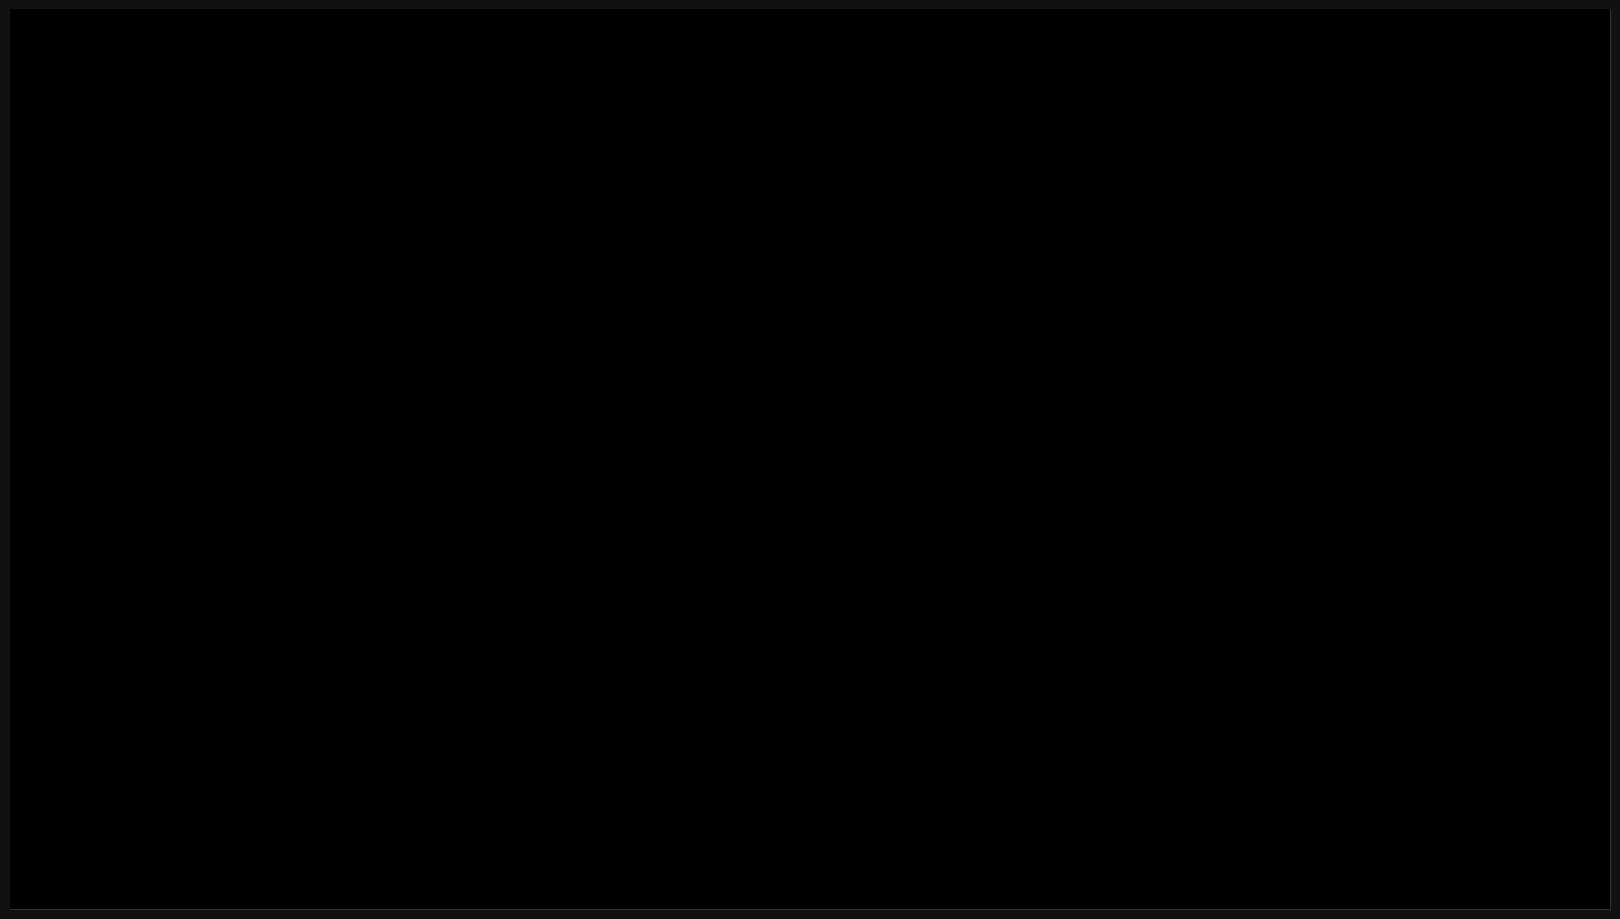

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter, label, binary_dilation, binary_erosion

# ── Config ────────────────────────────────────────────────────────────────────
W, H = 640, 480
RNG  = np.random.default_rng(42)

# Yellow circles in the static input image
STATIC_CIRCLES = [
    (220, 220, 90),   # cx, cy, r
    (420, 260, 75),
]

# Moving circles config for live stage: (cx0, cy0, vx, vy, r)
MOVING_CIRCLES = [
    (220, 220,  1.2,  0.7, 90),
    (420, 260, -0.9,  1.1, 75),
]

LIVE_FRAMES = 150

# ── Rendering helpers ─────────────────────────────────────────────────────────
def render_circles(circle_list, noise=0.03):
    img = np.zeros((H, W, 3), dtype=np.float32)
    img += RNG.uniform(0, noise, img.shape).astype(np.float32)
    yy, xx = np.mgrid[0:H, 0:W]
    for cx, cy, r in circle_list:
        dist = np.sqrt((xx-cx)**2 + (yy-cy)**2)
        core = dist < r
        ring = (dist >= r) & (dist < r+4)
        n = core.sum()
        img[core, 0] = np.clip(0.88 + RNG.uniform(-0.05, 0.05, n), 0, 1)
        img[core, 1] = np.clip(0.80 + RNG.uniform(-0.05, 0.05, n), 0, 1)
        img[core, 2] = np.clip(RNG.uniform(0, 0.06, n), 0, 1)
        img[ring, 0] = np.clip(img[ring,0] + 0.25, 0, 1)
        img[ring, 1] = np.clip(img[ring,1] + 0.15, 0, 1)
    return np.clip(img, 0, 1)

def yellow_mask(img):
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    return ((r > 0.55) & (g > 0.45) & (b < 0.3) & ((r+g) > 1.1)).astype(np.uint8)

def make_contour(mask):
    m = mask.astype(bool)
    return (binary_dilation(m) & ~binary_erosion(m)).astype(np.uint8)

def get_circles_from_mask(mask):
    """Return (cx, cy, r) estimates from labeled blobs."""
    lbl, n = label(mask)
    results = []
    for i in range(1, n+1):
        ys, xs = np.where(lbl == i)
        if len(xs) < 100: continue
        cx, cy = xs.mean(), ys.mean()
        r = np.sqrt(len(xs) / np.pi)
        results.append((cx, cy, r))
    return results

def moving_pos(idx, frame):
    cx0, cy0, vx, vy, r = MOVING_CIRCLES[idx]
    cx = cx0 + vx * frame
    cy = cy0 + vy * frame
    px = 2*(W-2*r); py = 2*(H-2*r)
    cx = cx % px; cy = cy % py
    if cx > W-2*r: cx = px - cx
    if cy > H-2*r: cy = py - cy
    return cx+r, cy+r, r

# ── Precompute static pipeline ────────────────────────────────────────────────
static_img     = render_circles([(cx,cy,r) for cx,cy,r in STATIC_CIRCLES])
static_mask    = yellow_mask(static_img)
static_contour = make_contour(static_mask)
static_circles = get_circles_from_mask(static_mask)

# Precompute live frames
print("Pre-rendering live frames...")
live_imgs     = []
live_masks    = []
live_contours = []
live_circs    = []
for f in range(LIVE_FRAMES):
    clist = [(moving_pos(i,f)) for i in range(len(MOVING_CIRCLES))]
    img = render_circles(clist, noise=0.02)
    msk = yellow_mask(img)
    live_imgs.append(img)
    live_masks.append(msk)
    live_contours.append(make_contour(msk))
    live_circs.append(get_circles_from_mask(msk))
print("Done.")

# ── Figure — RustyVision layout ───────────────────────────────────────────────
# Left: big main panel (DETECT)
# Right top: MASK
# Right mid: (spacer/label)
# Right bot: CONTOURS
fig = plt.figure(figsize=(16, 9), facecolor='#111111')

# Main panel: left 65%, right panels: top/bot 35%
ax_main    = fig.add_axes([0.00, 0.0,  0.65, 1.0])   # full left
ax_mask    = fig.add_axes([0.65, 0.50, 0.35, 0.50])  # top right
ax_contour = fig.add_axes([0.65, 0.00, 0.35, 0.50])  # bot right

for ax in [ax_main, ax_mask, ax_contour]:
    ax.set_facecolor('#000000')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')

# Panel labels (white text on black bg, like RustyVision)
def panel_tag(ax, text):
    ax.text(0.01, 0.98, text, transform=ax.transAxes,
            color='white', fontsize=9, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='square,pad=0.3', facecolor='black',
                      edgecolor='white', lw=1.2))

panel_tag(ax_main,    'DETECT (FINAL)')
panel_tag(ax_mask,    'MASK')
panel_tag(ax_contour, 'CONTOURS')

# ── Image artists ─────────────────────────────────────────────────────────────
# Main: show raw input first, then detection overlay
im_main    = ax_main.imshow(np.zeros((H,W,3)), origin='upper',
                             aspect='auto', extent=[0,W,H,0])
im_mask    = ax_mask.imshow(np.zeros((H,W)),   origin='upper',
                             aspect='auto', extent=[0,W,H,0], cmap='gray', vmin=0, vmax=1)
im_contour = ax_contour.imshow(np.zeros((H,W)), origin='upper',
                                aspect='auto', extent=[0,W,H,0], cmap='gray', vmin=0, vmax=1)

ax_main.set_xlim(0,W); ax_main.set_ylim(H,0)
ax_mask.set_xlim(0,W); ax_mask.set_ylim(H,0)
ax_contour.set_xlim(0,W); ax_contour.set_ylim(H,0)

# Dashed detection circles on main panel
det_circles_static = [plt.Circle((0,0), 1, fill=False, linestyle='--',
                                  edgecolor='white', lw=1.5, visible=False)
                      for _ in STATIC_CIRCLES]
det_circles_live   = [plt.Circle((0,0), 1, fill=False, linestyle='--',
                                  edgecolor='white', lw=1.5, visible=False)
                      for _ in MOVING_CIRCLES]
for c in det_circles_static + det_circles_live:
    ax_main.add_patch(c)

# Status text bottom of main panel
status_text = ax_main.text(W/2, H-12, '', color='white', fontsize=9,
                            ha='center', va='bottom',
                            bbox=dict(facecolor='black', edgecolor='none', alpha=0.7))

# Crosshair centres
cross_artists = [ax_main.plot([], [], '+', color='white', ms=12, mew=1.2)[0]
                 for _ in MOVING_CIRCLES]

# Tracking trails
TRAIL_LEN = 25
trail_lines = [ax_main.plot([], [], '-', color='#aaaaaa', lw=0.8, alpha=0.5)[0]
               for _ in MOVING_CIRCLES]
trail_hist  = [[] for _ in MOVING_CIRCLES]

# ── Stages ────────────────────────────────────────────────────────────────────
# S1  (40f): show raw input image
# S2  (50f): mask reveals (scan left→right)
# S3  (40f): contour fades in
# S4  (50f): detection circles draw in (dashed, radius expands)
# S5  (LIVE_FRAMES): live moving tracking
# S6  (40f): fade to black

S1, S2, S3, S4, S5, S6 = 40, 50, 40, 50, LIVE_FRAMES, 40
TOTAL = S1+S2+S3+S4+S5+S6

fade_ax   = fig.add_axes([0,0,1,1], zorder=30)
fade_ax.set_axis_off()
fade_rect = plt.Rectangle((0,0),1,1, transform=fade_ax.transAxes,
                            color='black', alpha=1.0)   # start black, fade in
fade_ax.add_patch(fade_rect)

def update(frame):

    # ── S1: fade in raw image ─────────────────────────────────────────────
    if frame < S1:
        progress = frame / S1
        im_main.set_data(static_img)
        im_mask.set_data(np.zeros((H,W)))
        im_contour.set_data(np.zeros((H,W)))
        for c in det_circles_static + det_circles_live: c.set_visible(False)
        for tl in trail_lines: tl.set_data([],[])
        for ch in cross_artists: ch.set_data([],[])
        status_text.set_text('INPUT IMAGE')
        fade_rect.set_alpha(max(1.0 - progress*2, 0.0))

    # ── S2: mask scan left→right ──────────────────────────────────────────
    elif frame < S1+S2:
        progress = (frame-S1)/S2
        x = int(progress * W)
        revealed = np.zeros((H,W), dtype=float)
        revealed[:, :x] = static_mask[:, :x].astype(float)
        im_mask.set_data(revealed)
        status_text.set_text('MASK  —  HSV yellow filter')
        fade_rect.set_alpha(0.0)

    # ── S3: contour fades in ──────────────────────────────────────────────
    elif frame < S1+S2+S3:
        progress = (frame-S1-S2)/S3
        im_mask.set_data(static_mask.astype(float))
        # Fade contour in
        contour_show = static_contour.astype(float) * progress
        im_contour.set_data(contour_show)
        status_text.set_text('CONTOURS  —  morphological edge')
        fade_rect.set_alpha(0.0)

    # ── S4: detection circles expand in ──────────────────────────────────
    elif frame < S1+S2+S3+S4:
        progress = (frame-S1-S2-S3)/S4
        im_contour.set_data(static_contour.astype(float))

        for i, (cx, cy, r) in enumerate(static_circles[:len(det_circles_static)]):
            c = det_circles_static[i]
            c.set_center((cx, cy))
            c.set_radius(r * min(progress * 1.5, 1.0))
            c.set_visible(True)
            c.set_alpha(min(progress * 2, 1.0))

        status_text.set_text(f'DETECTED  —  {len(static_circles)} circle(s) found')
        fade_rect.set_alpha(0.0)

    # ── S5: live tracking ─────────────────────────────────────────────────
    elif frame < S1+S2+S3+S4+S5:
        f = frame - S1 - S2 - S3 - S4

        img     = live_imgs[f]
        msk     = live_masks[f]
        contour = live_contours[f]
        circs   = live_circs[f]

        # Hide static detection circles
        for c in det_circles_static: c.set_visible(False)

        im_main.set_data(img)
        im_mask.set_data(msk.astype(float))
        im_contour.set_data(contour.astype(float))

        # Match live detected circles to moving circles by nearest centre
        for i in range(len(MOVING_CIRCLES)):
            px, py, pr = moving_pos(i, f)
            trail_hist[i].append((px, py))
            if len(trail_hist[i]) > TRAIL_LEN: trail_hist[i].pop(0)
            tarr = np.array(trail_hist[i])
            trail_lines[i].set_data(tarr[:,0], tarr[:,1])

            # Find best matching blob
            best = None; best_d = 1e9
            for (cx, cy, cr) in circs:
                d = np.sqrt((cx-px)**2 + (cy-py)**2)
                if d < best_d: best_d = d; best = (cx, cy, cr)

            if best and best_d < 80:
                cx, cy, cr = best
                det_circles_live[i].set_center((cx, cy))
                det_circles_live[i].set_radius(cr)
                det_circles_live[i].set_visible(True)
                det_circles_live[i].set_alpha(1.0)
                cross_artists[i].set_data([cx], [cy])
            else:
                det_circles_live[i].set_visible(False)
                cross_artists[i].set_data([],[])

        n = sum(1 for c in det_circles_live if c.get_visible())
        status_text.set_text(f'TRACKING  —  {n}/{len(MOVING_CIRCLES)} objects   frame {f}')
        fade_rect.set_alpha(0.0)

    # ── S6: fade out ──────────────────────────────────────────────────────
    else:
        progress = (frame-S1-S2-S3-S4-S5)/S6
        fade_rect.set_alpha(min(progress*1.5, 1.0))

    return ([im_main, im_mask, im_contour, fade_rect, status_text]
            + det_circles_static + det_circles_live
            + trail_lines + cross_artists)

ani = animation.FuncAnimation(fig, update, frames=TOTAL, interval=33, blit=True)
ani.save('object_detection.mp4', writer='ffmpeg', dpi=150)
print(f"Done — {TOTAL} frames")